# **Are traditional hitting stats enough to explain offensive value, or do Statcast/contact-quality metrics provide stronger insight into hitter performance?**



### By Cole Giuffrida

# 0. Setup

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

SEASON = 2025
MIN_PA = 200

DATA_URL = "https://raw.githubusercontent.com/cgiuffrida28/mlb-hitter-value-statcast/main/data/raw/stats.csv"

hitters_raw = pd.read_csv(DATA_URL)

print("Raw dataset shape:", hitters_raw.shape)
display(hitters_raw.head())

Raw dataset shape: (348, 48)


,"last_name, first_name",player_id,year,player_age,ab,pa,hit,single,double,triple,...,squared_up_swing,exit_velocity_avg,launch_angle_avg,barrel,barrel_batted_rate,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent
0,"Langeliers, Shea",669127,2025,27,481,523,133,70,32,0,...,24.5,90.9,16.4,43,11.3,44.9,102.509663,95.562115,25.1,52.4
1,"Barger, Addison",680718,2025,25,460,502,112,58,32,1,...,22.9,91.7,11.9,39,11.4,51.0,103.716707,96.416378,26.1,49.2
2,"Heim, Jonah",641680,2025,30,395,433,84,59,14,0,...,27.0,88.1,14.5,19,6.1,35.9,98.278416,93.298205,24.2,49.7
3,"Rice, Ben",700250,2025,26,467,530,119,61,28,4,...,31.2,93.3,14.2,57,15.4,56.1,104.138238,97.178139,21.2,43.3
4,"Pagés, Pedro",686780,2025,26,361,389,83,57,15,0,...,19.3,88.0,12.4,19,7.4,36.5,99.396807,93.764664,27.7,51.7


# 1. Introduction and Motivation

#### As is the case for many, sports are one of my favorite pastimes. While I didn't grow up playing baseball, I have recently become infatuated with the analytical side of the sport. I absolutely love playing fantasy sports, and projects like this scratch that itch perfectly. Baseball in particular is rich in both history and data, with stats measuring back to the late 19th century. Personally, I'm not very fond of these old stats because the game fundamentally changes every decade or so. Especially with records so old, is it really fair to say that Ty Cobb in the 1910's and his stats are comparable to today's game? That is the magic of these sports, and how we must judge each player in their respective time to truly appreciate their greatness.

#### There are many stats that we all know, whether we watch baseball or not: home runs, runs, stolen bases, just to name a few. A recent addition to the sport was Statcast in 2015, a deeper way to investigate aspects of the game that we couldn't before. New stats introduced with Statcast are exit velocity and launch angle, among many others. Together, these create the xwOBA stat, which estimates what a batter's at-bat should look like. It factors in strikeouts, walks, and, of course, quality of contact as well.

#### The stat wOBA will be what we focus on in this study. Is Statcast really necessary, or is it just another way to bloat stats in baseball?



# 2. Dataset Description

#### I will be using baseball savant for the data with a focus on the 2025 season. For better data from more relevant players, I will limit the minimum plate appearances for batters to 200. There are 3 main categories that we want several stats for:

#### 1.   Player info
#### 2.   Traditional stats
#### 3.   Statcast stats

#### To start, we need to be able to uniquely identify players. I'll list their name, season the data is pulled from, and the number of plate appearances they had.

#### For traditional stats, I'll focus on batting average, on base and slugging percentages separately, on base plus slugging percentage (OPS), homeruns, strikeout percentage, and walk percentage.

#### For Statcast stats, I'll focus on expected batting average, expected slugging percentage, expected weighted on base average (xwOBA), exit velocity, launch angle, barrel rate, and hard-hit rate.

#### Since these last two stats can be a little ambiguous, with their definition from Statcast not being super easy to understand, I will make note of them here. A barrel is a batted ball with a strong combination of exit velocity and launch angle. A hard-hit ball is counted when a ball is hit with an exit velocity of 95 mph or higher.



# 3. Cleaning

### Start with a copy, so that we aren't modifying the original csv file.

In [35]:
hitters = hitters_raw.copy()

### Update column names to be more understandable, changing % to percent, changing unnecessary symbols to underscores to be removed, etc.

In [36]:
def clean_column_name(col):
    col = col.strip().lower()
    col = col.replace('%', 'percent')
    col = col.replace('+', 'plus')
    col = col.replace('/', '_')
    col = col.replace('-', '_')
    col = col.replace(' ', '_')
    col = col.replace('.', '')
    col = col.replace(',', '')

    while '__' in col:
        col = col.replace('__', '_')

    return col.strip('_')


hitters.columns = [clean_column_name(col) for col in hitters.columns]

print('Standardized columns:')
print(hitters.columns.tolist())

Standardized columns:
['last_name_first_name', 'player_id', 'year', 'player_age', 'ab', 'pa', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout', 'walk', 'k_percent', 'bb_percent', 'batting_avg', 'slg_percent', 'on_base_percent', 'on_base_plus_slg', 'b_rbi', 'b_ab_scoring', 'b_gnd_into_dp', 'b_intent_walk', 'b_sac_bunt', 'b_sac_fly', 'r_run', 'b_walkoff', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'xiso', 'avg_swing_speed', 'fast_swing_rate', 'blasts_contact', 'blasts_swing', 'squared_up_contact', 'squared_up_swing', 'exit_velocity_avg', 'launch_angle_avg', 'barrel', 'barrel_batted_rate', 'hard_hit_percent', 'avg_best_speed', 'avg_hyper_speed', 'whiff_percent', 'swing_percent']


### Update column names now to be more accurate to their stat.

In [37]:
rename_map = {
    # Player / season columns
    'last_name_first_name': 'player_name',
    'player_id': 'player_id',
    'year': 'season',
    'player_age': 'age',

    # Playing time
    'ab': 'ab',
    'pa': 'pa',

    # Traditional  stats
    'hit': 'hits',
    'single': 'singles',
    'double': 'doubles',
    'triple': 'triples',
    'home_run': 'hr',
    'strikeout': 'strikeouts',
    'walk': 'walks',
    'b_rbi': 'rbi',
    'r_run': 'runs',
    'batting_avg': 'ba',
    'on_base_percent': 'obp',
    'slg_percent': 'slg',
    'on_base_plus_slg': 'ops',
    'k_percent': 'strikeout_percent',
    'bb_percent': 'walk_percent',

    # Statcast stats
    'xba': 'xba',
    'xslg': 'xslg',
    'woba': 'woba',
    'xwoba': 'xwoba',
    'xobp': 'xobp',
    'xiso': 'xiso',

    # Swing / contact-quality stats
    'avg_swing_speed': 'avg_swing_speed',
    'fast_swing_rate': 'fast_swing_rate',
    'blasts_contact': 'blasts_contact',
    'blasts_swing': 'blasts_swing',
    'squared_up_contact': 'squared_up_contact',
    'squared_up_swing': 'squared_up_swing',
    'exit_velocity_avg': 'avg_exit_velocity',
    'launch_angle_avg': 'launch_angle',
    'barrel': 'barrels',
    'barrel_batted_rate': 'barrel_percent',
    'hard_hit_percent': 'hard_hit_percent',
    'avg_best_speed': 'avg_best_speed',
    'avg_hyper_speed': 'avg_hyper_speed',
    'whiff_percent': 'whiff_percent',
    'swing_percent': 'swing_percent'
}

hitters = hitters.rename(columns=rename_map)

print('Columns after renaming:')
print(hitters.columns.tolist())

Columns after renaming:
['player_name', 'player_id', 'season', 'age', 'ab', 'pa', 'hits', 'singles', 'doubles', 'triples', 'hr', 'strikeouts', 'walks', 'strikeout_percent', 'walk_percent', 'ba', 'slg', 'obp', 'ops', 'rbi', 'b_ab_scoring', 'b_gnd_into_dp', 'b_intent_walk', 'b_sac_bunt', 'b_sac_fly', 'runs', 'b_walkoff', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'xiso', 'avg_swing_speed', 'fast_swing_rate', 'blasts_contact', 'blasts_swing', 'squared_up_contact', 'squared_up_swing', 'avg_exit_velocity', 'launch_angle', 'barrels', 'barrel_percent', 'hard_hit_percent', 'avg_best_speed', 'avg_hyper_speed', 'whiff_percent', 'swing_percent']


### Update player names to be first last instead of last, first.

In [38]:
# Before to show name order
display(hitters[['player_name', 'player_id', 'season', 'pa']].head())

def fix_player_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip()

    if ',' in name:
        parts = name.split(',')
        if len(parts) == 2:
            last = parts[0].strip()
            first = parts[1].strip()
            return f'{first} {last}'

    return name


hitters['player_name'] = hitters['player_name'].apply(fix_player_name)

display(hitters[['player_name', 'player_id', 'season', 'pa']].head())

,player_name,player_id,season,pa
0,"Langeliers, Shea",669127,2025,523
1,"Barger, Addison",680718,2025,502
2,"Heim, Jonah",641680,2025,433
3,"Rice, Ben",700250,2025,530
4,"Pagés, Pedro",686780,2025,389


,player_name,player_id,season,pa
0,Shea Langeliers,669127,2025,523
1,Addison Barger,680718,2025,502
2,Jonah Heim,641680,2025,433
3,Ben Rice,700250,2025,530
4,Pedro Pagés,686780,2025,389


### Verify plate appearances are above the threshold of 200.

In [39]:
print('Minimum PA in dataset:', hitters['pa'].min())
print('Players below PA threshold:', (hitters['pa'] < MIN_PA).sum())

hitters = hitters[hitters['pa'] >= MIN_PA].copy()

print('Shape after PA threshold validation:', hitters.shape)

Minimum PA in dataset: 204
Players below PA threshold: 0
Shape after PA threshold validation: (348, 48)


### Check for missing values. There shouldn't be any.

In [40]:
missing_summary = (
    hitters.isna()
    .sum()
    .to_frame('missing_count')
)

missing_summary['missing_percent'] = (
    missing_summary['missing_count'] / len(hitters) * 100
).round(2)

missing_summary = missing_summary.sort_values('missing_count', ascending=False)

display(missing_summary.head(20))

total_missing = hitters.isna().sum().sum()
print('Total missing values:', total_missing)

,missing_count,missing_percent
player_name,0,0.0
player_id,0,0.0
season,0,0.0
age,0,0.0
ab,0,0.0
pa,0,0.0
hits,0,0.0
singles,0,0.0
doubles,0,0.0
triples,0,0.0


Total missing values: 0


### Confirm all columns are numeric.

In [41]:
numeric_cols = [
    'season', 'age', 'ab', 'pa',
    'hits', 'singles', 'doubles', 'triples', 'hr',
    'strikeouts', 'walks', 'rbi', 'runs',
    'k_percent', 'bb_percent',
    'avg', 'obp', 'slg', 'ops',
    'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'xiso',
    'avg_swing_speed', 'fast_swing_rate',
    'blasts_contact', 'blasts_swing',
    'squared_up_contact', 'squared_up_swing',
    'avg_exit_velocity', 'launch_angle',
    'barrels', 'barrel_percent', 'hard_hit_percent',
    'avg_best_speed', 'avg_hyper_speed',
    'whiff_percent', 'swing_percent'
]

numeric_cols = [col for col in numeric_cols if col in hitters.columns]

for col in numeric_cols:
    hitters[col] = pd.to_numeric(hitters[col], errors='coerce')

hitters[numeric_cols].dtypes

,0
season,int64
age,int64
ab,int64
pa,int64
hits,int64
singles,int64
doubles,int64
triples,int64
hr,int64
strikeouts,int64


### Now remove unnecessary columns that don't deal with our core stats (wOBA).

In [42]:
analysis_cols = [
    # Player information
    'player_name',
    'player_id',
    'season',
    'age',
    'pa',
    'ab',

    # Traditional hitting stats
    'hits',
    'singles',
    'doubles',
    'triples',
    'hr',
    'rbi',
    'runs',
    'strikeouts',
    'walks',
    'k_percent',
    'bb_percent',
    'avg',
    'obp',
    'slg',
    'ops',

    # Offensive value / expected stats
    'woba',
    'xwoba',
    'xba',
    'xslg',
    'xobp',
    'xiso',

    # Contact quality / swing metrics
    'avg_exit_velocity',
    'launch_angle',
    'barrels',
    'barrel_percent',
    'hard_hit_percent',
    'avg_swing_speed',
    'fast_swing_rate',
    'blasts_contact',
    'blasts_swing',
    'squared_up_contact',
    'squared_up_swing',
    'avg_best_speed',
    'avg_hyper_speed',
    'whiff_percent',
    'swing_percent'
]

analysis_cols = [col for col in analysis_cols if col in hitters.columns]

hitters_clean = hitters[analysis_cols].copy()

print('Cleaned dataset shape:', hitters_clean.shape)

required_cols = [
    'player_name',
    'pa',
    'woba',
    'xwoba',
    'avg',
    'obp',
    'slg',
    'ops'
]

required_cols = [col for col in required_cols if col in hitters_clean.columns]

before_rows = len(hitters_clean)

hitters_clean = hitters_clean.dropna(subset=required_cols).copy()

after_rows = len(hitters_clean)

print('Rows before dropping missing required values:', before_rows)
print('Rows after dropping missing required values:', after_rows)

# No rows removed from our removal of certain columns.

print('Rows removed:', before_rows - after_rows)

Cleaned dataset shape: (348, 39)
Rows before dropping missing required values: 348
Rows after dropping missing required values: 348
Rows removed: 0


### Now verify our file to see if we missed anything.

In [43]:
print('Final cleaned shape:', hitters_clean.shape)

print('Season values:')
print(hitters_clean['season'].value_counts())

print('\nPA range:')
print(hitters_clean['pa'].min(), 'to', hitters_clean['pa'].max())

print('\nDuplicate player IDs:')
print(hitters_clean.duplicated('player_id').sum())

Final cleaned shape: (348, 39)
Season values:
season
2025    348
Name: count, dtype: int64

PA range:
204 to 732

Duplicate player IDs:
0


# 4. Analysis

### 1. What is the distribution of wOBA?

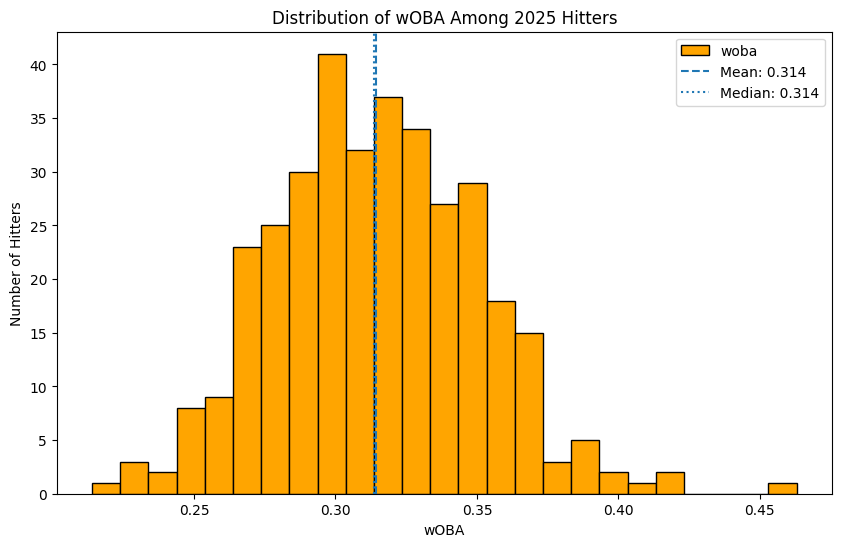

In [44]:
plt.figure(figsize=(10, 6))
hitters_clean['woba'].plot.hist(bins=25, title='Distribution of wOBA Among 2025 Hitters', xlabel='wOBA', ylabel='Number of Hitters', color='orange', edgecolor='black')

mean_woba = hitters_clean['woba'].mean()
median_woba = hitters_clean['woba'].median()

plt.axvline(mean_woba, linestyle='--', label=f'Mean: {mean_woba:.3f}')
plt.axvline(median_woba, linestyle=':', label=f'Median: {median_woba:.3f}')
plt.legend()
plt.show()

#### From this graph, we can see that most hitters will fall between about 0.27 and 0.37 wOBA. There are outliers among hitters who are both below and above this range, showcasing poor and excellent hitting, with one batter posting an above-0.45 wOBA. Additionally, the mean and median are the same, showing there isn't a skew in either direction.

### 2. What is the distribution of xwOBA?

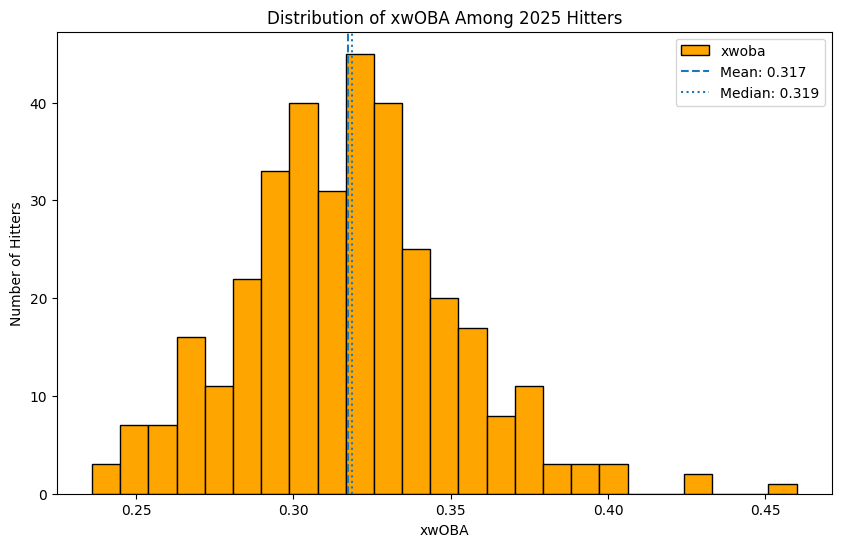

In [45]:
plt.figure(figsize=(10, 6))
hitters_clean['xwoba'].plot.hist(bins=25, title='Distribution of xwOBA Among 2025 Hitters', xlabel='xwOBA', ylabel='Number of Hitters', color='orange', edgecolor='black')

mean_woba = hitters_clean['xwoba'].mean()
median_woba = hitters_clean['xwoba'].median()

plt.axvline(mean_woba, linestyle='--', label=f'Mean: {mean_woba:.3f}')
plt.axvline(median_woba, linestyle=':', label=f'Median: {median_woba:.3f}')
plt.legend()
plt.show()

#### From this graph, we can see that there are a few differences from the previous one. One of the similarities is the average batter's xwOBA, which is roughly the same as with wOBA, falling between 0.28 and 0.36. One difference is with the mean and median, with the median being slightly higher than the mean. This means that there are a few batters with a very low xwOBA that are dragging the mean below the median, indicating a slight left skew.

### 3. What is the comparison between OPS and wOBA?

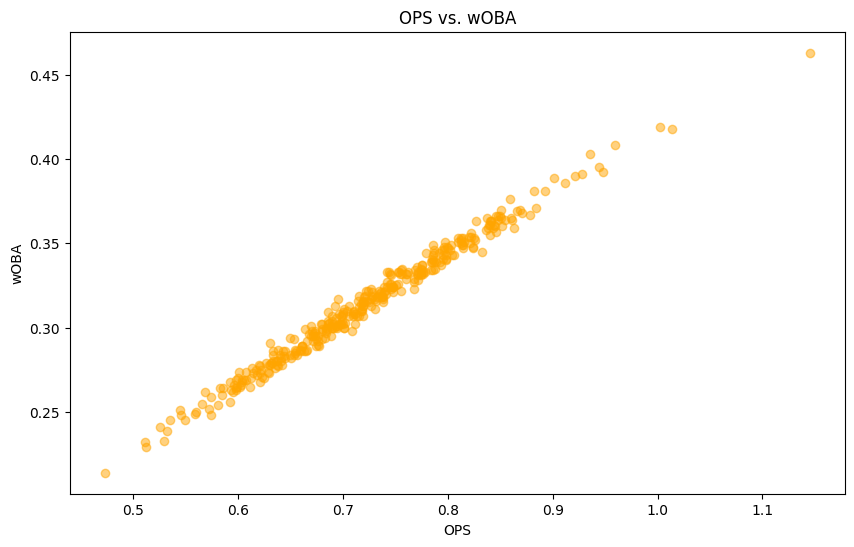

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(hitters_clean['ops'], hitters_clean['woba'], alpha=0.5, color='orange')
plt.title('OPS vs. wOBA')
plt.xlabel('OPS')
plt.ylabel('wOBA')
plt.show()

#### It seems that OPS and wOBA have a very strong positive correlation. This is because OPS is a traditional stat that measures the outcome of a play for a hitter. Since wOBA is also based on the outcome of a play, it makes sense that there would be a strong overlap.

### 4. What is the comparison between xwOBA and wOBA?

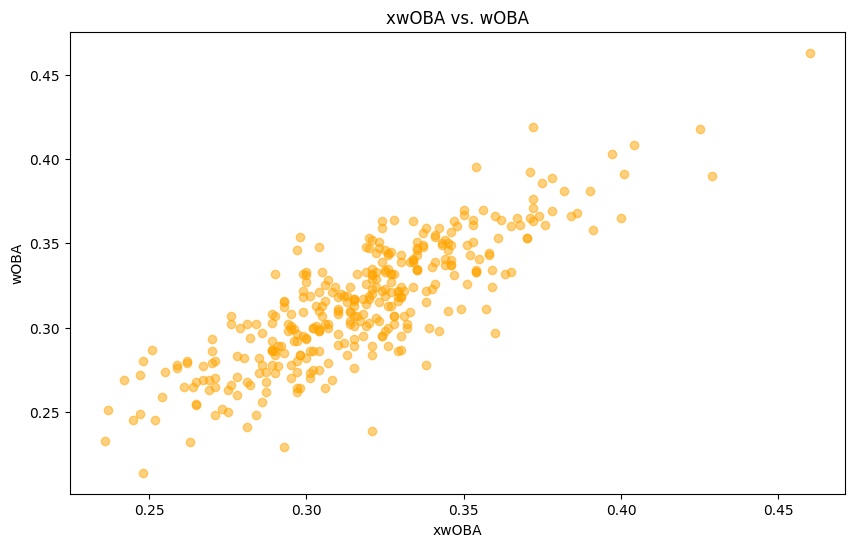

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(hitters_clean['xwoba'], hitters_clean['woba'], alpha=0.5, color='orange')
plt.title('xwOBA vs. wOBA')
plt.xlabel('xwOBA')
plt.ylabel('wOBA')
plt.show()

#### This plot shows how expected performance compares to actual performance. As we can see, there isn't as strong of a correlation between the two when compared to the last plot, but there is enough overlap to suggest strong correlation.

### 5. What is the comparison between Barrel% and wOBA?

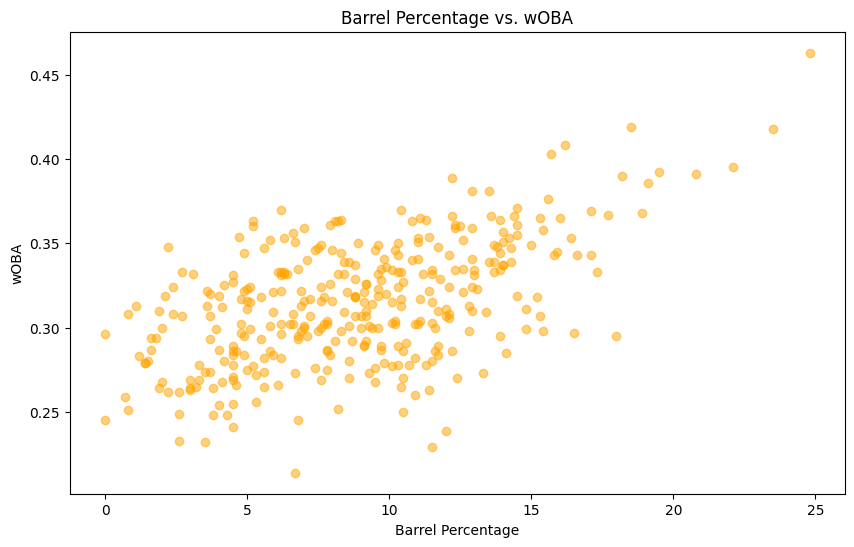

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(hitters_clean['barrel_percent'], hitters_clean['woba'], alpha=0.5, color='orange')
plt.title('Barrel Percentage vs. wOBA')
plt.xlabel('Barrel Percentage')
plt.ylabel('wOBA')
plt.show()

#### This plot is even less correlated than the last. Barrel percentage is important to compare to wOBA because it shows how elite contact may not necessarily relate to high offensive value. A lot of the points on the plot show a low to medium wOBA regardless of whether barrel percent is high or low, with the elite hitters being high in both.

### 6. What is the comparison between Hard-Hit% and wOBA?

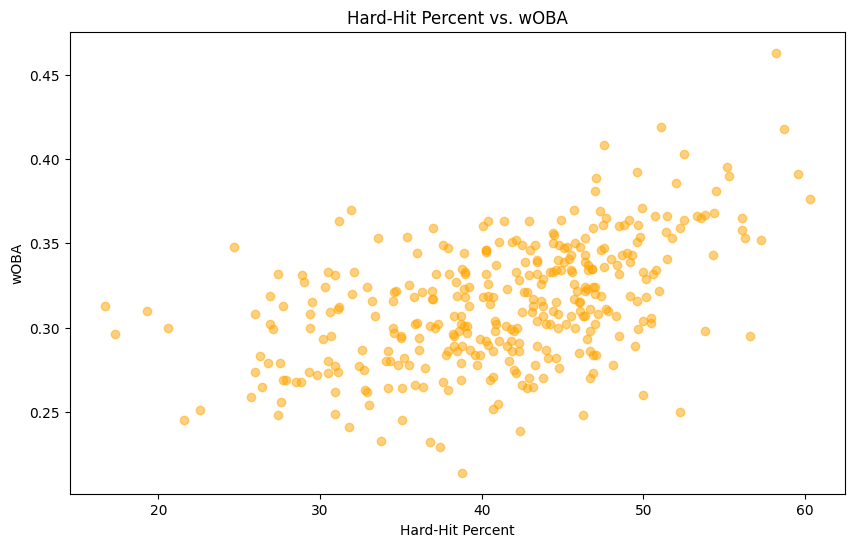

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(hitters_clean['hard_hit_percent'], hitters_clean['woba'], alpha=0.5, color='orange')
plt.title('Hard-Hit Percent vs. wOBA')
plt.xlabel('Hard-Hit Percent')
plt.ylabel('wOBA')
plt.show()

#### As was seen with barrel percent, hard hit percent also doesn't have a very strong correlation to wOBA and overall performance. Oneil Cruz is a good example of this, a player who hits the ball harder than anyone else, but maybe lacks the ability to get on base consistently, leading to a lower wOBA. It seems that many players with average to below average hard hit percent wind up with about the same wOBA, while hitters with above a 47% hard hit rate become the above average examples.

### 7. Is there an overarching correlation between traditional stats and Statcast stats?

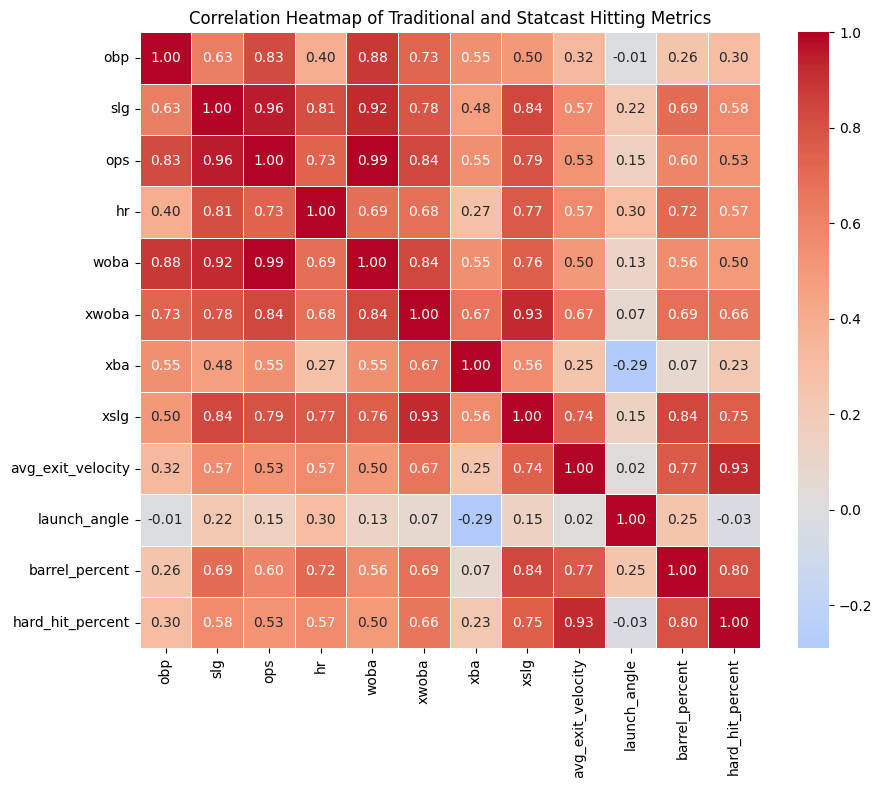

In [50]:
heatmap_cols = [
    # Traditional stats
    'avg',
    'obp',
    'slg',
    'ops',
    'hr',
    'k_percent',
    'bb_percent',

    # Statcast / expected stats
    'woba',
    'xwoba',
    'xba',
    'xslg',
    'avg_exit_velocity',
    'launch_angle',
    'barrel_percent',
    'hard_hit_percent'
]

# Keep only columns that exist in the dataset
heatmap_cols = [col for col in heatmap_cols if col in hitters_clean.columns]

corr_matrix = hitters_clean[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Traditional and Statcast Hitting Metrics')
plt.show()

#### This heatmap shows the relationships between all the metrics, but it can be a little difficult to understand. Since our focus is on wOBA, an additional bar graph may help us interpret the relationship between traditional and advanced metrics.

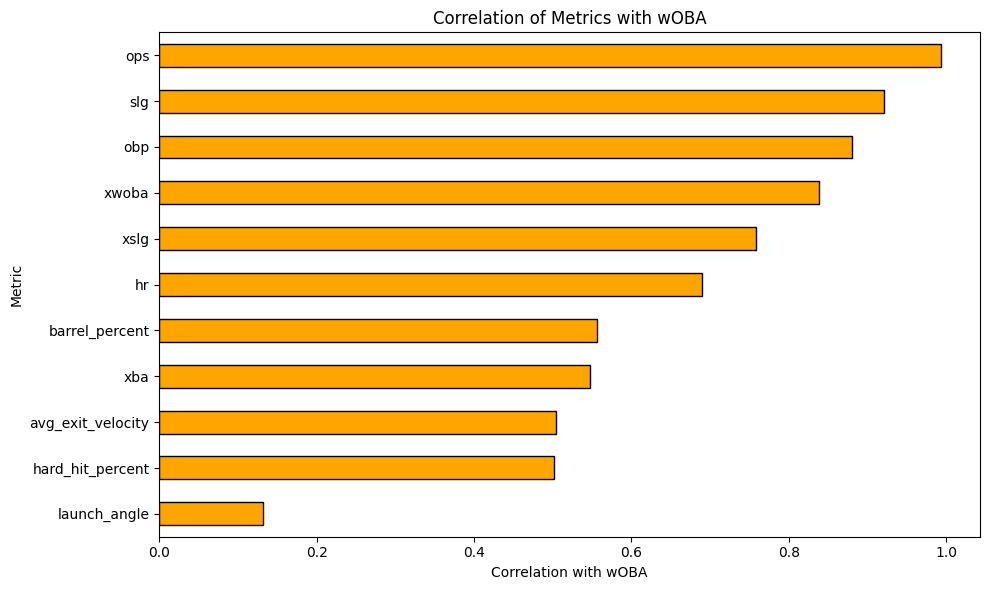

In [51]:
woba_correlations = (corr_matrix['woba'].drop('woba').sort_values(ascending=False))

plt.figure(figsize=(10, 6))

woba_correlations.sort_values().plot(kind='barh', color='orange', edgecolor='black')

plt.title('Correlation of Metrics with wOBA')
plt.xlabel('Correlation with wOBA')
plt.ylabel('Metric')

plt.tight_layout()
plt.show()

#### From this bar plot, we can see the correlation to wOBA much clearer. As was the case before, OPS and wOBA have a high correlation since they are both outcome-based stats. Since OPS is made up of slugging and obp, it makes sense for those two to be the next highest correlated metrics. xwOBA and xSLG being the next few are to be expected since they measure expected results.

#### An interesting perspective to this is that traditional stats only capture actual outcomes, whereas Statcast metrics also account for the quality of contact and what the result should have been. It takes into account how maybe some great defensive plays take away what would be a hit on any other given play. That is why it is important to ask questions like if traditional stats tell the whole story, or not, as they only care for outcomes and not all contact that could result in a hit.

#### xSLG and xwOBA are results of this perspective, but it makes sense to see correlation to a players overall performance from these since they're expected versions of the other stats. Homeruns and barrel percent also are self-explanatory since players who hit many home runs or harder balls in general are typically better hitters. The reason hard hit percent ranks lower is because it is just how fast the ball comes off the bat without taking into account launch angle, meaning a hard hit ball could be a ground ball and out. This is kind of the case with launch angle and average exit velocity as well, because there isn't a connection of these stats individually that point to strong hitting.

### 8. Who are the top overperformers of the 2025 season?

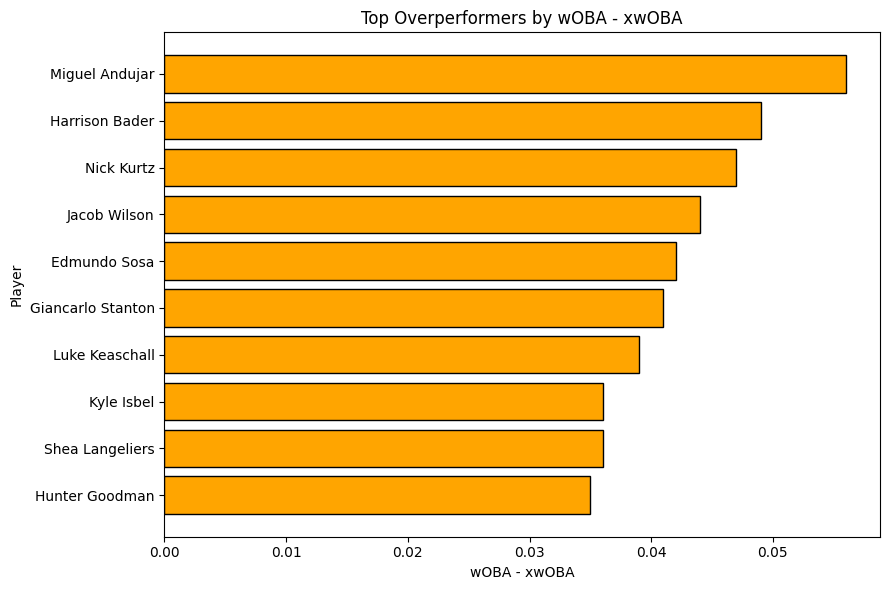

In [52]:
performance = hitters_clean.copy()

performance['woba_minus_xwoba'] = performance['woba'] - performance['xwoba']
overperformers = (performance.sort_values('woba_minus_xwoba', ascending=False).head(10))

plt.figure(figsize=(9, 6))

plt.barh(overperformers['player_name'], overperformers['woba_minus_xwoba'], color='orange', edgecolor='black')

plt.title('Top Overperformers by wOBA - xwOBA')
plt.xlabel('wOBA - xwOBA')
plt.ylabel('Player')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### We can see that the top overperformers of the 2025 season are a combination of both well-known players as well as some younger, lesser known players. Nick Kurtz is a good example of a younger player overperforming since he had such a big year, but seeing his teammate Jacob Wilson just below him is surprising. It shows how performance isn't only measured on huge numbers of runs, RBI's or home runs, but also batting average and contact in general. Other notable names on the list are Harrison Bader who is now on my Giants, Giancarlo Stanton, Shea Langeliers (Another Athletic), and Hunter Goodman.

### 9. Who were the most disappointing hitters of the 2025 season?

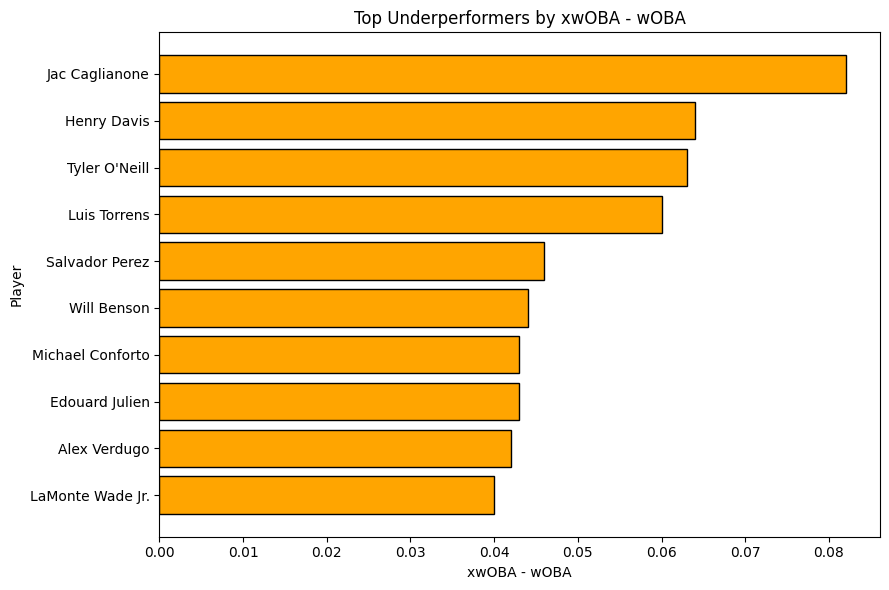

In [53]:
performance['xwoba_minus_woba'] = performance['xwoba'] - performance['woba']
underperformers = (performance.sort_values('xwoba_minus_woba', ascending=False).head(10))

plt.figure(figsize=(9, 6))

plt.barh(underperformers['player_name'], underperformers['xwoba_minus_woba'], color='orange', edgecolor='black')

plt.title('Top Underperformers by xwOBA - wOBA')
plt.xlabel('xwOBA - wOBA')
plt.ylabel('Player')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### The top underperformers are now mostly young players and regressing veterans. Most notably are Salvador Perez and Michael Conforto who have been great throughout their careers. Perez has obviously been better than Conforto, who has been on a downturn since his injury, but it is sad to see one of the better players of this generation in Perez start to decline. His teammate Jac Caglianone is just starting his career, and I think it is unfair to judge rookie players too harshly. Yes, it is hard to see one of the highly anticipated prospects struggle when another rookie in Kurtz, is so spectacular, but we as fans need to remember to be patient before we judge.

#### Other notable names are Alex Verdugo and LaMonte Wade Jr., although neither are spectacular players by any means.

# 5. Modeling

### We can start with our setup. I will use linear regression as my model, and we can start by defining the groups we will use.

In [54]:
target_col = 'woba'

traditional_features = ['avg', 'obp', 'slg', 'ops', 'hr', 'k_percent', 'bb_percent']

statcast_features = ['xba', 'xslg', 'xwoba', 'avg_exit_velocity', 'launch_angle', 'barrel_percent', 'hard_hit_percent']

combined_features = traditional_features + statcast_features

### Now lets only keep columns that are in our cleaned dataset.

In [55]:
traditional_features = [col for col in traditional_features if col in hitters_clean.columns]
statcast_features = [col for col in statcast_features if col in hitters_clean.columns]
combined_features = [col for col in combined_features if col in hitters_clean.columns]

print("Traditional features:", traditional_features)
print("Statcast features:", statcast_features)
print("Combined features:", combined_features)

Traditional features: ['obp', 'slg', 'ops', 'hr']
Statcast features: ['xba', 'xslg', 'xwoba', 'avg_exit_velocity', 'launch_angle', 'barrel_percent', 'hard_hit_percent']
Combined features: ['obp', 'slg', 'ops', 'hr', 'xba', 'xslg', 'xwoba', 'avg_exit_velocity', 'launch_angle', 'barrel_percent', 'hard_hit_percent']


### Next, lets create our model's dataset.

In [56]:
model_cols = [target_col] + combined_features

model_data = hitters_clean[model_cols].dropna().copy()

print("Modeling dataset shape:", model_data.shape)
display(model_data.head())

Modeling dataset shape: (348, 12)


,woba,obp,slg,ops,hr,xba,xslg,xwoba,avg_exit_velocity,launch_angle,barrel_percent,hard_hit_percent
0,0.364,0.325,0.536,0.861,31,0.251,0.463,0.328,90.9,16.4,11.3,44.9
1,0.322,0.301,0.454,0.755,21,0.255,0.462,0.331,91.7,11.9,11.4,51.0
2,0.266,0.271,0.332,0.603,11,0.219,0.346,0.276,88.1,14.5,6.1,35.9
3,0.358,0.337,0.499,0.836,26,0.280,0.553,0.391,93.3,14.2,15.4,56.1
4,0.276,0.272,0.363,0.635,11,0.208,0.340,0.259,88.0,12.4,7.4,36.5


### Now lets create our training and testing data.

In [57]:
X = model_data[combined_features]
y = model_data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 261
Testing rows: 87


### With all our training and testing data, as well as our feature groups, lets create the model.

In [58]:
# Create the model
# R² tells us the variation in woba, want higher
# RMSE is the average prediction error, want lower

def evaluate_linear_model(model_name, feature_cols):
    X_train_subset = X_train[feature_cols]
    X_test_subset = X_test[feature_cols]

    model = Pipeline([('scaler', StandardScaler()), ('regression', LinearRegression())])

    model.fit(X_train_subset, y_train)

    y_pred = model.predict(X_test_subset)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        'model': model_name,
        'features': feature_cols,
        'r2': r2,
        'rmse': rmse,
        'fitted_model': model
    }

### Finally, lets train our model onto our three datasets.

In [59]:
traditional_result = evaluate_linear_model('Traditional Stats', traditional_features)

statcast_result = evaluate_linear_model('Statcast Metrics', statcast_features)

combined_result = evaluate_linear_model('Combined Model', combined_features)

model_results = [traditional_result, statcast_result, combined_result]

### Now with our models trained, lets compare our results. To put this visually, I will also provide a graph showing our R², or the wOBA prediction accuracy.

,Model,Number of Features,R²,RMSE
2,Combined Model,11,0.996927,0.001853
0,Traditional Stats,4,0.996254,0.002046
1,Statcast Metrics,7,0.626787,0.020424


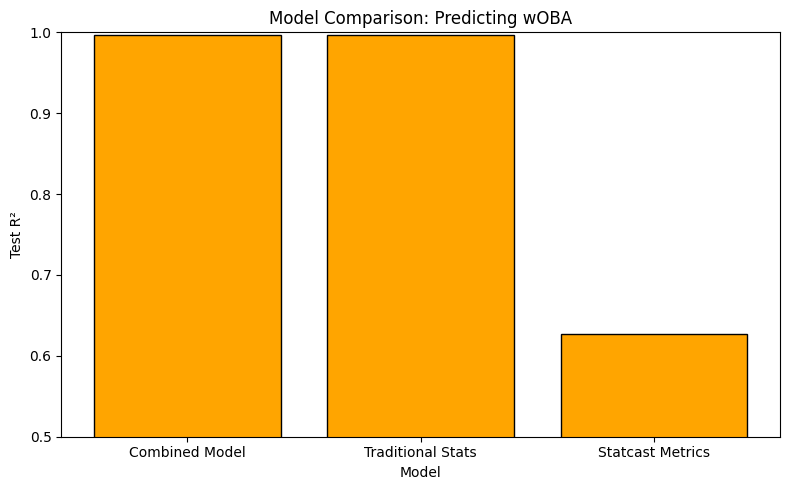

In [60]:
results_table = pd.DataFrame([
    {
        'Model': result['model'],
        'Number of Features': len(result['features']),
        'R²': result['r2'],
        'RMSE': result['rmse']
} for result in model_results])

results_table = results_table.sort_values('R²', ascending=False)

display(results_table)

plt.figure(figsize=(8, 5))

plt.bar(results_table['Model'], results_table['R²'], color='orange', edgecolor='black')

plt.title('Model Comparison: Predicting wOBA')
plt.xlabel('Model')
plt.ylabel('Test R²')

plt.ylim(0.5, 1)

plt.tight_layout()
plt.show()

### As stated in a comment in our setup, we want a high R² and a low RMSE. To state again, R² represents variation in our data, and a higher percentage means we were more accurate with our predictions. RMSE should be lower as it represents error.

### In this case, the combined model is just slightly better in both R² and RMSE compared to traditional stats. This means that traditional stats already explain a lot for a hitters performance. The statcast model, being almost 0.4 R² lower and 0.02 RMSE higher than the traditional model, show that expected stats and contact-quality metrics actually may not be as informative as they may seem on their own.

### Now we can use Cross-Validation to confirm our findings and assumptions that Traditional stats may be enough to accurately describe a hitter's performance.

In [61]:
def cross_validate_model(model_name, feature_cols):
    X_subset = model_data[feature_cols]
    y_subset = model_data[target_col]

    model = Pipeline([('scaler', StandardScaler()), ('regression', LinearRegression())])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    r2_scores = cross_val_score(model, X_subset, y_subset, cv=cv, scoring='r2')

    neg_mse_scores = cross_val_score(model, X_subset, y_subset, cv=cv, scoring='neg_mean_squared_error')

    rmse_scores = np.sqrt(-neg_mse_scores)

    return {
        'Model': model_name,
        'CV Mean R²': r2_scores.mean(),
        'CV R² Std': r2_scores.std(),
        'CV Mean RMSE': rmse_scores.mean(),
        'CV RMSE Std': rmse_scores.std()
    }


### With our cross-validation model created, lets run it for all of our models.

In [62]:
# Run for all three models

cv_results = pd.DataFrame([
    cross_validate_model('Traditional Stats', traditional_features),
    cross_validate_model('Statcast Metrics', statcast_features),
    cross_validate_model('Combined Model', combined_features)
])

cv_results = cv_results.sort_values('CV Mean R²', ascending=False)

display(cv_results)

,Model,CV Mean R²,CV R² Std,CV Mean RMSE,CV RMSE Std
2,Combined Model,0.997298,0.000592,0.001854,0.000288
0,Traditional Stats,0.996640,0.000905,0.002060,0.000369
1,Statcast Metrics,0.673004,0.093289,0.019995,0.001248


### This table can be a little confusing to understand. Lets use coefficients to help explain what the model is.

In [63]:
combined_model = combined_result['fitted_model']

coefficients = combined_model.named_steps['regression'].coef_

coef_table = pd.DataFrame({
    'Feature': combined_features,
    'Coefficient': coefficients
})

coef_table['Absolute Coefficient'] = coef_table['Coefficient'].abs()

coef_table = coef_table.sort_values('Absolute Coefficient', ascending=False)

display(coef_table)

,Feature,Coefficient,Absolute Coefficient
2,ops,0.014494,0.014494
1,slg,0.014318,0.014318
0,obp,0.011432,0.011432
6,xwoba,0.004919,0.004919
5,xslg,-0.004216,0.004216
4,xba,-0.001399,0.001399
7,avg_exit_velocity,-0.000721,0.000721
3,hr,-0.000687,0.000687
10,hard_hit_percent,0.000666,0.000666
8,launch_angle,-0.000279,0.000279


### To help us interpret these coefficients, let's visualize them.

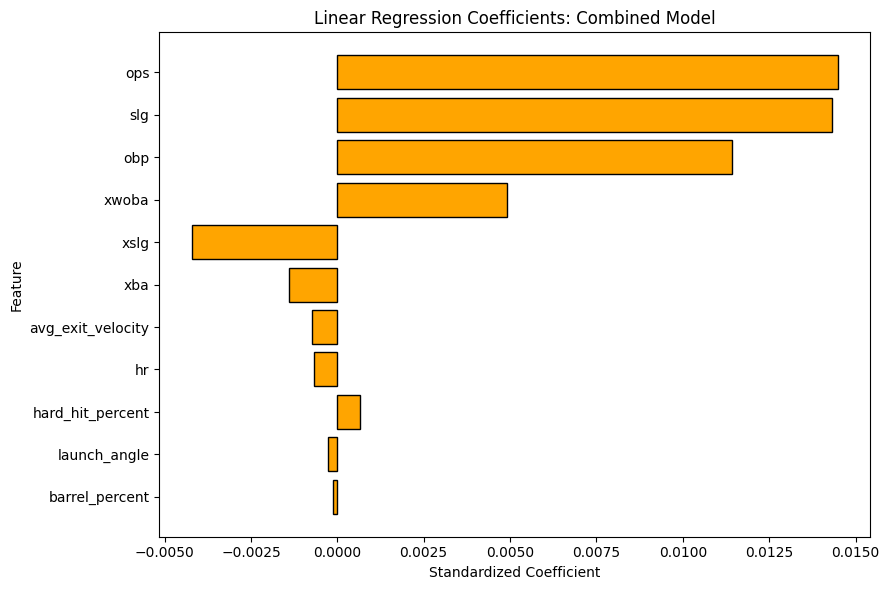

In [64]:
plt.figure(figsize=(9, 6))

plt.barh(coef_table['Feature'], coef_table['Coefficient'], color='orange', edgecolor='black')

plt.title('Linear Regression Coefficients: Combined Model')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Feature')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### At first glance, it may seem like traditional stats are better overall for determining a hitters performance. The last graph suggested that, and this one further provides evidence to that hypothesis. This isn't necessarily true, however, because traditional stats are based on offensive results.

### Of course hitters with better traditional stats seem better because that is what traditional stats are designed to do; reflect offensive performance, but only for what actually happened. What happens then with Statcast metrics that captures how well the ball was hit regardless of outcome?

### Statcast metrics provide a different perspective because they estimate the quality of a hitter's performance. Because the combined model from earlier had an improvement to just the traditional model, albeit small, it strongly suggests that Statcast metrics add useful information beyond traditional stats alone. While not necessarily great on their own, Statcast does provide some value.

# 6. Limitations

### There are some important notes to make about this study. First, we only looked at one season. There can be trends in here that are real, and some that are fake. That means that results can just be noise, and isn't necessarily true for all seasons. Our limit of 200 plate appearances also filters our dataset to a few hundred players, leaving many out. This not only limits our dataset to established hitters, but also limits the reliability of our regression model since our sample size is small. To build on this, since OPS is a result of OBP and SLG, the traditional model will have multicollinearity that will inflate R². We know this is true because R² for both the traditional model and combined model were about 0.996, which is suspiciously high.

# 7. Conclusion

### We started with the question, "Are traditional stats enough to make an assumption on a hitter's performance?" We started with our analysis of what wOBA was, focusing on the distribution among hitters with more than 200 plate appearances. Then we showed the distribution of xWOBA, showing the distribution of expected results. To further understand wOBA, we directly compared it with OPS, xwOBA, barrel percentage, and hard hit percent. By showing the correlation of wOBA with both traditional stats and Statcast metrics (With traditional stats having a tighter correlation), we can get a little preview of what to expect when we get to our models.

### We then directly showed the correlation between wOBA and all of our metrics, specifically OPS, SLG, OBP, xWOBA, xSLG, HR, barrel percent, xBA, average exit velocity, hard hit percent, and launch angle. We saw that traditional stats were more tightly correlated with wOBA, which makes sense as traditional stats are based on results.

### After that, we took a look at who the top overperformers and underperformers were. For overperformers, we found that there was a mix of players who had an outlier year, playing above their typical range, as well as younger players who went above and beyond their expectations. For the more disappointing players, we found that there were a few young players who unfortunately didn’t live up to the hype, as well as some fading superstars and overall mediocre players performing poorly.

### Starting with our linear model, we found that traditional stats actually did predict a hitter’s wOBA significantly better than just Statcast metrics. That strongly suggests that while Statcast metrics may not be significantly accurate on their own, they do provide a boost to accuracy when combined with traditional stats.

### To answer the question, then, traditional stats are surprisingly enough to judge a hitter’s performance. There is a reason that traditional metrics have always been used, after all. The addition of Statcast metrics is not useless, however, and it is important to note that. The purpose of Statcast metrics is to build on what we already know about a hitter, not necessarily to judge based on only these new stats. When combining traditional and Statcast, we can get the most complete picture of a hitter’s performance.